In [1]:
# librerias
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, partial_trace, DensityMatrix,negativity,state_fidelity,Operator,concurrence,entropy
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke


from qiskit_dynamics import Solver, Signal
from qiskit_dynamics.backend import parse_backend_hamiltonian_dict

from qiskit import pulse
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import numpy as np
import random
import sympy as sym

import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")

In [2]:
import numpy as np
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt

def plot_statevector_probabilities_qudit(statevector, d=2):
    """
    Grafica probabilidades de un statevector de qudits.
    Usa etiquetas en base d (por defecto qubits: d=2).
    """
    probabilities = statevector.probabilities()
    dim = len(probabilities)
    
    # Número de qudits
    num_qudits = int(round(np.log(dim) / np.log(d)))
    
    # Etiquetas en base d (por ejemplo base=3 para qutrits)
    basis_states = []
    for i in range(dim):
        digits = np.base_repr(i, base=d).zfill(num_qudits)
        basis_states.append(f"|{digits}⟩")
    
    # Gráfico
    plt.figure(figsize=(12,5))
    plt.bar(basis_states, probabilities, color='royalblue')
    plt.xlabel(f'Computational basis states ',fontsize=20)
    plt.ylabel('Probability',fontsize=20)
    # plt.title(f'Measurement Probabilities of {num_qudits} qudits (d={d})',fontsize=20)
    plt.ylim(0, 1.0)
    plt.xticks(rotation=0,fontsize=16)
    plt.yticks(fontsize=14)
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [3]:
# Llamar fake backend
backend = FakeSherbrooke()

#configuracion de backend
propiedades = backend.properties()
configuracion = backend.configuration()


Hz = 1e9
# Definicion de la frecuencia de los qubits en GHz
w7   = configuracion.hamiltonian.get("vars").get("wq7")
w8   = configuracion.hamiltonian.get("vars").get("wq8")
w9   = configuracion.hamiltonian.get("vars").get("wq9")
# anamornicidad de los qubits en GHz
delta7 = configuracion.hamiltonian.get("vars").get("delta7")
delta8 = configuracion.hamiltonian.get("vars").get("delta8")
delta9 = configuracion.hamiltonian.get("vars").get("delta9")
# acoples en GHz
J78 = configuracion.hamiltonian.get("vars").get("jq7q8")
J89 = configuracion.hamiltonian.get("vars").get("jq8q9")
# fuerza de control en GHz
r0   =  configuracion.hamiltonian.get("vars").get("omegad7")
r1   =  configuracion.hamiltonian.get("vars").get("omegad8")
r2   =  configuracion.hamiltonian.get("vars").get("omegad9")
# tiempo de gate en ns
dt = backend.dt*1e9


v7 = w7 /(2*np.pi)
v8 = w8 /(2*np.pi)
v9 = w9 /(2*np.pi)
print(v7, v8, v9)
print(delta7, delta8, delta9)
print(J78, J89)
print(r0, r1, r2)

4.755587722216812 4.812531480182586 4.637614165110824
-1.9540951675249636 -1.9688054129735373 -1.8387169285946419
0.012651918734551187 0.014172096168429698
0.39575797919595557 0.6501466069370565 0.3148551427122911


In [4]:
# Definir los operadores 
dim = 2
a = np.diag(np.sqrt(np.arange(1, dim)), 1)
adag = np.diag(np.sqrt(np.arange(1, dim)), -1)
N = np.diag(np.arange(dim))

ident = np.eye(dim, dtype=complex)
full_ident = np.eye(dim**2, dtype=complex)

N0 =np.kron(ident, N)
N1 = np.kron(N, ident)


a0 = np.kron(ident, a)
a1 = np.kron(a, ident)



a0dag = np.kron(ident, adag)
a1dag = np.kron(adag, ident)


# Haniltoniano del sistema
static_ham = 2*np.pi*v7 * N0+   delta7*(a0dag@a0dag@a0@a0)/2   + 2*np.pi*v8 * N1+   delta8*(a1dag@a1dag@a1@a1)/2  + J78*(a0dag @ a1 +  a0 @ a1dag) 

# Hamiltonianos de controles
H_drive7 =  r0 * (a0 + a0dag)
H_drive8 =  r1 * (a1 + a1dag)

  

# y0 = Statevector([1,0,0]).tensor(Statevector([1,0,0])).tensor(Statevector([1,0,0]))
y0  = Statevector.from_label("00")

In [5]:
# Solucionar la ecuación de Schrödinger
solver  = Solver(static_hamiltonian=static_ham,
                 hamiltonian_operators=[H_drive7, H_drive8,H_drive7],
                 hamiltonian_channels=["d0", "d1","u0"],
                 channel_carrier_freqs= {"d0": v7, "d1": v8, "u0": v8},
                 dt=dt,
                 array_library="jax")

In [6]:
from qiskit import pulse

def esque_pul(params):
    t_0, t_1, A0, A1, A2  = params

    # Convertir a enteros por requerimiento del backend
    t_0 = int(t_0)
    t_1 = int(t_1)
   
    with pulse.build(name="pulso Bell state") as kp:
        d0 = pulse.DriveChannel(0)
        d1 = pulse.DriveChannel(1)
        u0 = pulse.ControlChannel(0)
       

        # Primer pulso en d0 y d1
        pulse.play(pulse.Constant(duration=t_0, amp=A0), d0)
        pulse.play(pulse.Constant(duration=t_0, amp=A1), d1)
        
    
        # Delay en canal u0
        pulse.delay(duration= t_0 + 1, channel=u0)
        
        # Segundo pulso en d1 y u0
        pulse.play(pulse.Constant(duration = t_1 , amp=A2), u0)
      
          
    return kp
   

In [7]:
def objective_12(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=y0,
        signals=signal,
        method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    yf = sol.y[-1]/np.linalg.norm(sol.y[-1])
    return yf

In [8]:
parametros_optimos_2 = [
        191.910934,
        797.242687,
        0.6824432988764655,
        0.8286644926788276,
        0.7868326972398657,
    ]

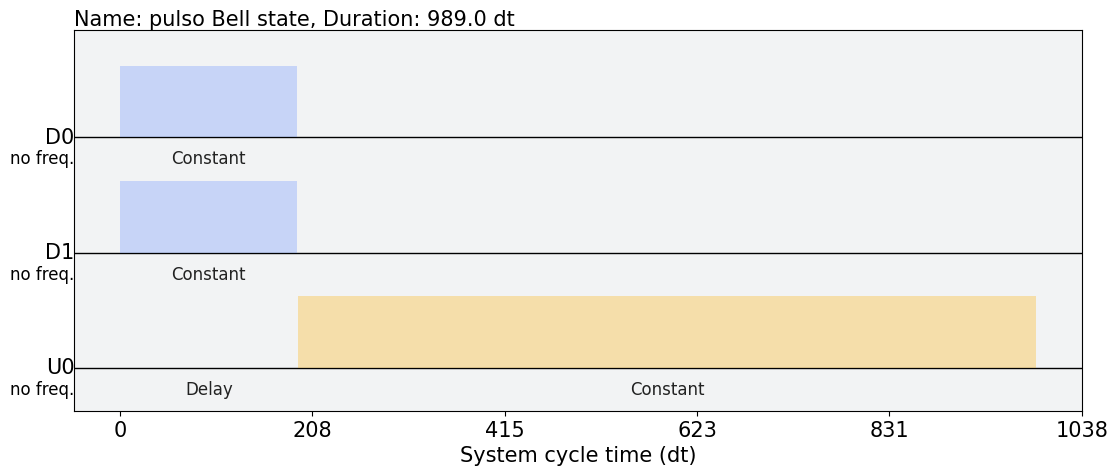

In [9]:
esque_pul(parametros_optimos_2).draw()

In [10]:
esque_pul(parametros_optimos_2).duration

989

In [11]:
objective_12(parametros_optimos_2).draw("latex")

<IPython.core.display.Latex object>

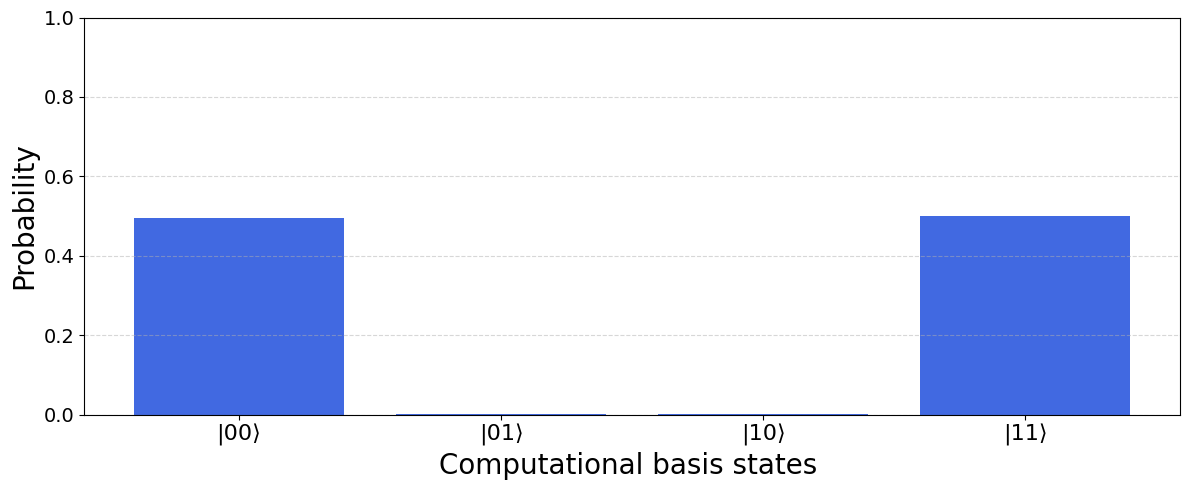

In [12]:
plot_statevector_probabilities_qudit(objective_12(parametros_optimos_2), d=2)

In [13]:
negativity(objective_12(parametros_optimos_2),[0])

np.float64(0.49984127342556195)

In [14]:
concurrence(objective_12(parametros_optimos_2))

0.9996825468511237

In [15]:
# Definir los operadores 
dim = 3
a = np.diag(np.sqrt(np.arange(1, dim)), 1)
adag = np.diag(np.sqrt(np.arange(1, dim)), -1)
N = np.diag(np.arange(dim))

ident = np.eye(dim, dtype=complex)
full_ident = np.eye(dim**2, dtype=complex)

N0 =np.kron(ident, N)
N1 = np.kron(N, ident)


a0 = np.kron(ident, a)
a1 = np.kron(a, ident)



a0dag = np.kron(ident, adag)
a1dag = np.kron(adag, ident)


# Haniltoniano del sistema
static_ham = 2*np.pi*v7 * N0+   delta7*(a0dag@a0dag@a0@a0)/2   + 2*np.pi*v8 * N1+   delta8*(a1dag@a1dag@a1@a1)/2  + J78*(a0dag @ a1 +  a0 @ a1dag) 

# Hamiltonianos de controles
H_drive7 =  r0 * (a0 + a0dag)
H_drive8 =  r1 * (a1 + a1dag)

  

y0 = np.array([1,0,0,0,0,0,0,0,0])
# y0  = Statevector.from_label("00")

In [16]:
# Solucionar la ecuación de Schrödinger
solver  = Solver(static_hamiltonian=static_ham,
                 hamiltonian_operators=[H_drive7, H_drive8,H_drive7],
                 hamiltonian_channels=["d0", "d1","u0"],
                 channel_carrier_freqs= {"d0": v7, "d1": v8, "u0": v8},
                 dt=dt,
                 array_library="jax")

In [17]:
from qiskit import pulse

def esque_pul(params):
    """Create a pulse schedule for a Bell state.

    Args:
        params (list): A list containing the parameters for the Gaussian pulses.

    Returns:
        _type_: Sigma1, sigma2, duration1, duration2,sigma3, duration3,
        
        Corresponding to each Gaussian pulse respectively.
        
        dura1, sigma1: Parameters for the first Gaussian pulse
        
        dura2, sigma2: Parameters for the second Gaussian pulse
        
        dura3, sigma3: Parameters for the third Gaussian pulse.
        
        
    1st pulse on d0 and d1
    
    2nd pulse on u0
    
    dura1 > with1
    
    dura2 > with1
    
    dura3 > with3
    
    1st and 2nd pulse with the same width
    
    in this case with1 = 191.910934 and with3 = 797.242687
    
    Amplitudes are fixed based on previous optimizations.
    """
    dura1, sigma1, dura3, sigma3,  = params
    
    dura1 = int(dura1)
    dura2 = int(dura1)
    dura3 = int(dura3)
    sigma1 = int(sigma1)
    sigma2 = int(sigma1)
    sigma3 = int(sigma3)
    
    width1 =  191.910934
    width3 =  797.242687

    width1 = int(width1)
    width3 = int(width3)

    amp1  =  0.6824432988764655
    amp2  =  0.8286644926788276
    amp3  =  0.7868326972398657
    
    # dura = int(dura2/2)
   
    
    with pulse.build(name="Bell Pulse") as bell:
        
        d0 = pulse.DriveChannel(0)
        d1 = pulse.DriveChannel(1)
        u0 = pulse.ControlChannel(0)
        

        # primer pulso en d0 y d1
        pulse.play(pulse.GaussianSquare(dura1, amp1, sigma1, width1), d0)
        pulse.play(pulse.GaussianSquare(dura2, amp2, sigma2, width1), d1)

        # pulso de control en u0
        pulse.delay(  dura1, u0)
        pulse.play(pulse.GaussianSquare(dura3, amp3, sigma3, width3), u0)
    
    return bell

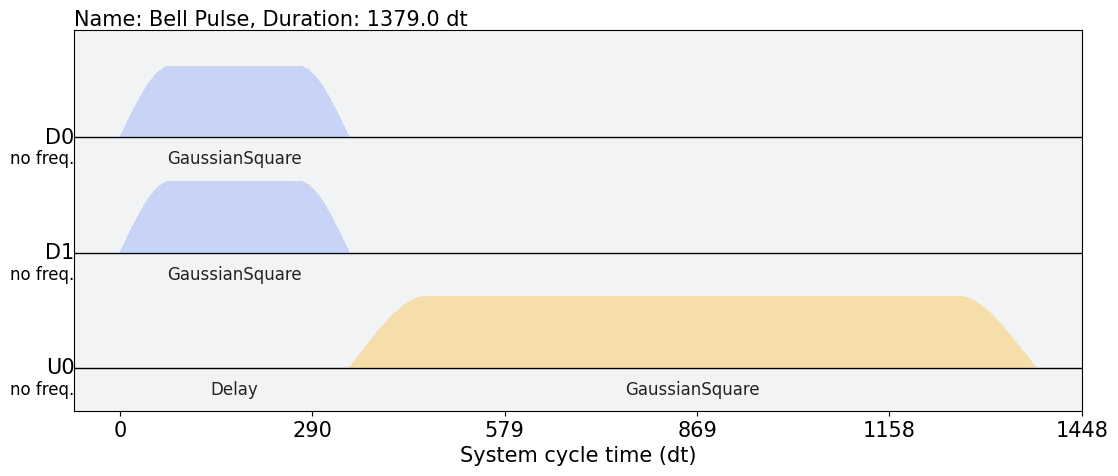

In [19]:
esque_pul([ 3.454e+02,  7.218e+01,  1.034e+03,  9.756e+01]).draw()

In [59]:
# fun_objetivo
def evo_bell_state(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=y0,
        signals=signal,
        method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    yf = sol.y[-1]/np.linalg.norm(sol.y[-1])


    redu_vector = [] 
    for i in [0,1,3,4]:
        redu_vector.append(yf[i])
    yr = np.array(redu_vector)/np.linalg.norm(redu_vector)



    # rho_bc = partial_trace(Statevector(yr), [0])
    # rho_ac = partial_trace(Statevector(yr), [1])
    # rho_ab = partial_trace(Statevector(yr), [2])

    # cost = (negativity(rho_ab,[0]) - 0.5)**2
    return yr,yf

In [60]:
esta = evo_bell_state( [3.454e+02,  7.218e+01,  1.034e+03,  9.756e+01])

In [62]:
y = np.array([ 4.38067802e-01+2.89725211e-01j,  1.15937148e-01-4.58286548e-01j, -4.84790772e-04-2.21179624e-03j, -4.00385492e-01-2.63044372e-01j,
           8.99644938e-02-5.12795133e-01j, -2.32995363e-03+2.33153412e-03j,
           7.77661208e-03-4.50609086e-03j,  3.58356896e-03+4.99615097e-03j,
           -4.48991831e-06-3.56743551e-05j])

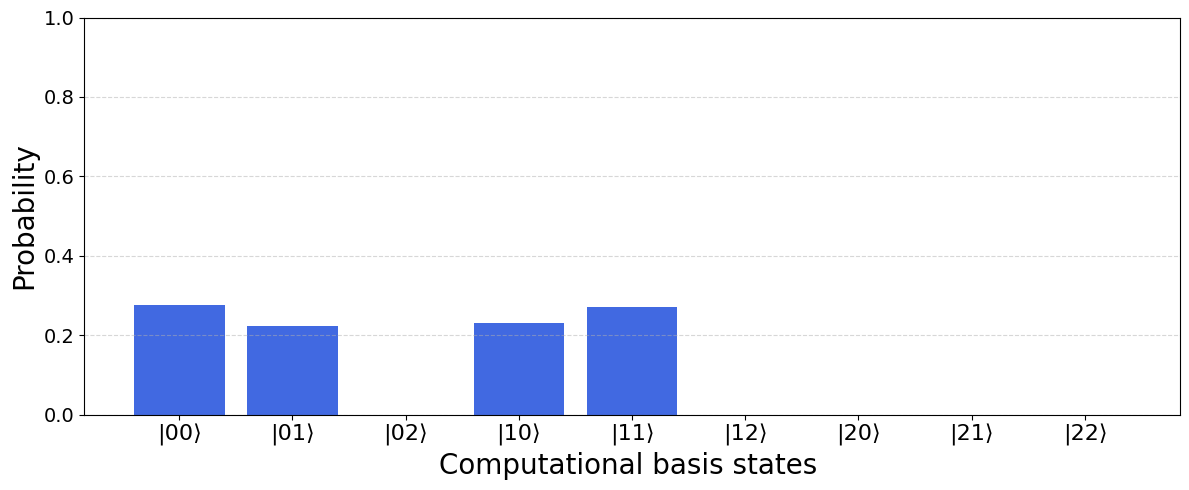

In [63]:
plot_statevector_probabilities_qudit(Statevector(y), d=3)

In [64]:
negativity(Statevector(esta[0]),[0])

np.float64(0.4996567733080405)

In [65]:
concurrence(Statevector(esta[0]))

0.9993135466160815

In [66]:
Statevector(esta[0])

Statevector([ 0.43809728+0.28974471j,  0.11594495-0.45831739j,
             -0.40041244-0.26306207j,  0.08997055-0.51282964j],
            dims=(2, 2))


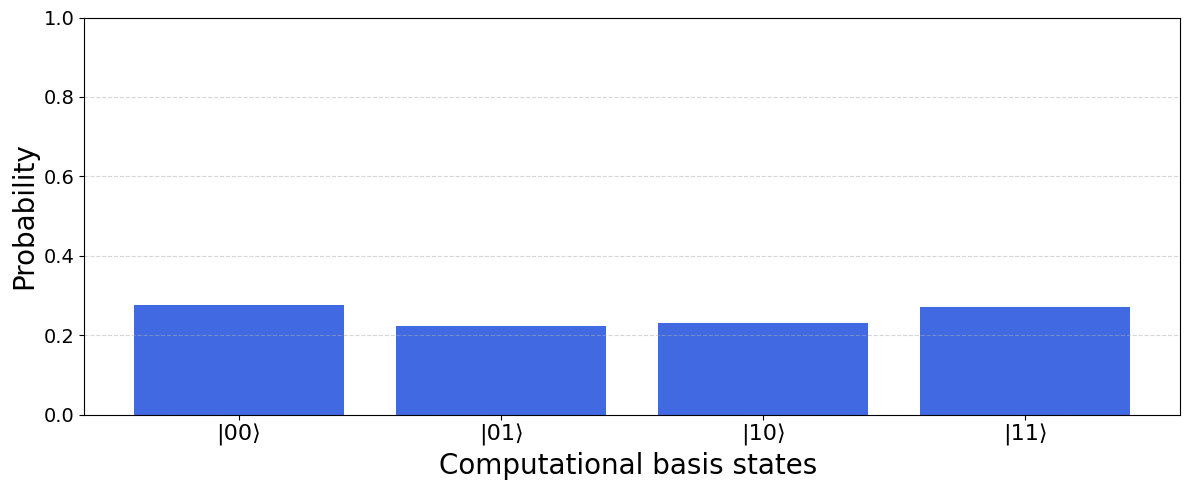

In [68]:
plot_statevector_probabilities_qudit(Statevector(Statevector(esta[0])), d=2)